In [1]:
""" Carbon fluxes in Paul's observations """
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from utils.constants import *
from utils.paths import *
from utils.plotting import *
from utils.analysis import *
from scipy.stats import linregress, t
from utils.analysis import get_spruce_carbonfluxes

prefix_list = ['UQ_20231113_2a','UQ_20231113_2b','UQ_20231113_2c','UQ_20231113_2d']
N_list = [768,768,768,256]
BLOCK_LIST = [192,192,192,256]

In [2]:
def get_obs():
    """ Get the observational slope & value at ambient chamber """
    plot_list = [f'P{p:02g}' for p in chamber_list_complete]

    obs_data = get_spruce_carbonfluxes().set_index(['Plot', 'Year'])
    t2m_obs = obs_data.loc[:, 'Mean Annual Temp. at 2 m']
    obs_data = obs_data.loc[:, ["ABGnpp shrub", "ANPP Shrub (~50%C)"]]

    collection = pd.DataFrame(np.nan, index = ['amb', 'elev'],
                              columns = ['slope', 'slope_std'])

    for co2 in ['amb','elev']:
        if co2 == 'amb':
            filt = obs_data.index.get_level_values(0).isin([plot_list[0]] + plot_list[1::2])
        else:
            filt = obs_data.index.get_level_values(0).isin(plot_list[2::2])

        obs_temp = obs_data.loc[filt, :].values.reshape(-1)
        obs_T    = t2m_obs.loc[filt].values
        obs_T    = np.vstack([obs_T,obs_T]).T.reshape(-1)

        filt2 = ~np.isnan(obs_T) & ~np.isnan(obs_temp)
        obs_temp = obs_temp[filt2]
        obs_T = obs_T[filt2]

        res = linregress(obs_T, obs_temp)

        ts = abs(t.ppf(0.05, len(obs_T) - 2))

        collection.loc[co2, 'slope'] = res.slope
        collection.loc[co2, 'slope_std'] = ts * res.stderr

    return collection

In [3]:
# the dimensions are:
#   N sims x VAR_LIST x (amb, elev) x (mean, mean_std, slope, ts * slope_std)
VAR_LIST = ["TOTVEGC_ABG_pima", "TOTVEGC_ABG_lala", "TOTVEGC_ABG_shrub",
            "ANPP_pima", "ANPP_lala", "ANPP_tree", "ANPP_shrub", 
            "NPP_moss", "BGNPP", "HR", "NEE", "TOTSOMC"]

collection_sim = {}
for N, BLOCK, prefix in zip(N_list, BLOCK_LIST, prefix_list):
    collect = np.empty([N, len(VAR_LIST), 2, 4], float)
    for b in range(0, N // BLOCK):
        collect[(b*BLOCK):((b + 1)*BLOCK), :, :] = np.load(os.path.join(path_out, "extract", prefix, f"ensemble_collection_part{b:03g}.bin"), allow_pickle=True)
    # convert Inf's to NaN
    collect = np.where(~((collect == np.inf) | (collect == -np.inf)), collect, np.nan)
    # convert unit from gC m-2 s-1 (per year) to gC m-2 (per year)
    collect[:, 3:, :, :] = collect[:, 3:, :, :] * 365 * 86400
    # revert the signs of NEE & HR to be compatible with Paul's data
    collect[:, -3:-1, :, :] = - collect[:, -3:-1, :, :]
    # Select only shrub ANPP
    collection_sim[prefix] = collect[:, 6, :, :]

In [4]:
collection_obs = get_obs()
collection_obs

,slope,slope_std
amb,4.497894,2.215810
elev,7.751008,2.821086


[Text(1.5, 0, 'UQ_20231113_2a'),
 Text(3.5, 0, 'UQ_20231113_2b'),
 Text(5.5, 0, 'UQ_20231113_2c'),
 Text(7.5, 0, 'UQ_20231113_2d')]

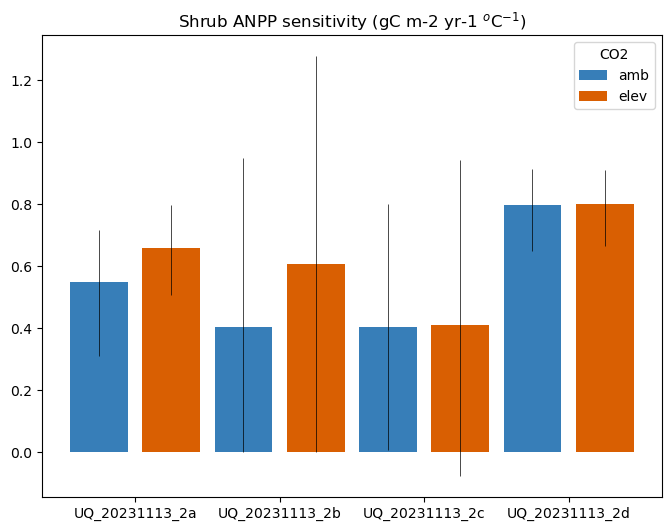

In [21]:
fig, ax = plt.subplots(figsize = (8, 6))

#ax.bar([1, 2], collection_obs.loc[:, 'slope'].values, 
#       color = ['#074e67', '#14dcdc'])
#ax.errorbar([1, 2], collection_obs['slope'].values, 
#            collection_obs['slope_std'].values, 
#            ecolor = 'k', lw = 0, elinewidth = 0.5)
ax.set_title('Shrub ANPP sensitivity (gC m-2 yr-1 $^o$C$^{-1}$)')

k = 2 # select slope
for j, prefix in enumerate(prefix_list):
    temp = np.nanmean(collection_sim[prefix][:, :, k], axis = 0)
    temp_q5 = np.nanpercentile(collection_sim[prefix][:, :, k], 5, axis = 0)
    temp_q95 = np.nanpercentile(collection_sim[prefix][:, :, k], 95, axis = 0)

    h = ax.bar([1+j*2, 2+j*2], temp, color = ['#377eb8', '#d95f02'])
    ax.errorbar([1+j*2, 2+j*2], temp, [temp - temp_q5, temp_q95 - temp], 
                ecolor = 'k', lw = 0, elinewidth = 0.5)
    
    if j == 0:
        ax.legend(h, ['amb','elev'], title = 'CO2')

ax.set_xticks(np.arange(1.5, 1.5 + 2 * len(prefix_list)-0.5, 2))
#ax.set_xticklabels(['OBS_ACO2', 'OBS_ECO2'] + [f'{a}\n{prefix}' for prefix in prefix_list for a in  ['SIM_ACO2', 'SIM_ECO2']])
ax.set_xticklabels(prefix_list)